# Task 10.2 C
### Name: Nay Tun
### Student Id: 225110052
### Google colab link https://colab.research.google.com/github/nay-deakin/sit720-data/blob/main/NayTun225110052_Task10.2C.ipynb

# 1. Load the MINIST Digit dataset, show the size of the training and test set.

In [1]:
import tensorflow as tf
from tensorflow import keras
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()


In [3]:
print (f"Size of test set: {len(x_test)}")
print (f"Size of train set: {len(x_train)}")

Size of test set: 10000
Size of train set: 60000


### Sizes
|Sets|Size|
|------|------|
|Train|60000 rows|
|Test|10000 rows|

#


# 2. Develop a one hidden layer multi-layer perceptron model on the above training data, report the accuracy of the model.

### Reashape from 2D 28x28 to 1D and normalize

In [4]:
x_train_1d = x_train.reshape(x_train.shape[0],-1) / 255
x_test_1d = x_test.reshape(x_test.shape[0],-1) / 255


In [5]:
mlp_clf = MLPClassifier(
    hidden_layer_sizes=[100,]
    ,random_state=1
    ,max_iter=300
)

mlp_clf.fit(x_train_1d, y_train)
pred = mlp_clf.predict(x_test_1d)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



### Overall accuracy is 0.98 or the 10,000 dataset with one hidden layer.
### The worse peforming class is, digits 8 and 9 because of their similar shapes.
### the best ones are 0 and 1 due to distinct shape.  0 is distince from 1
### Overall it generalizes well accross all 10 classes with balanced precision and recall.

#

# 3. From question 2, set the number of hidden layers of the MLP model as [2,4,6,8,10], set the hidden layer size as 100, show the accuracies on the test set. 

In [18]:
neurons = 100
layers = [2,4,6,8,10]
test_scores = []
train_scores = []
for l in layers:
    mlp_clf = MLPClassifier(
        hidden_layer_sizes=[neurons] * l
        ,random_state=1
        ,max_iter=300
    )
    mlp_clf.fit(x_train_1d, y_train)
    score = mlp_clf.score(x_test_1d, y_test)
    test_scores.append(score)
    print (f"Layer {l} score: {score}")
    score = mlp_clf.score(x_train_1d, y_train)
    train_scores.append(score)
    




Layer 2 score: 0.9784
Layer 4 score: 0.9788
Layer 6 score: 0.9798
Layer 8 score: 0.9764
Layer 10 score: 0.9777


In [20]:
train_scores

[0.9989666666666667,
 0.9981333333333333,
 0.9980833333333333,
 0.9978166666666667,
 0.9982]

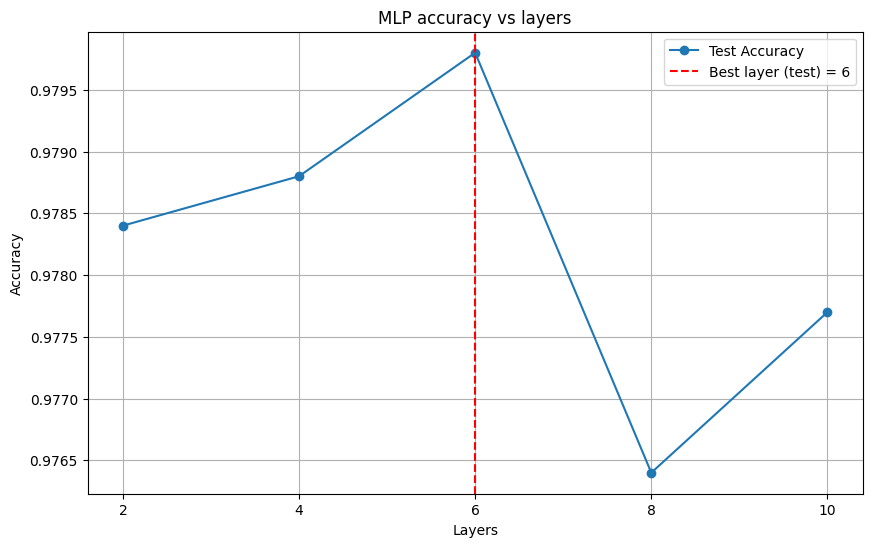

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(layers, test_scores, label='Test Accuracy', marker='o')
#plt.plot(layers, train_scores, label='Train Accuracy', marker='x')
plt.xlabel('Layers')
plt.ylabel('Accuracy')
plt.title('MLP accuracy vs layers')
plt.legend()
plt.xticks(layers)
plt.grid(True)

# Mark best layer
best_layer = layers[test_scores.index(max(test_scores))]
plt.axvline(x=best_layer, color='red', linestyle='--', label=f'Best layer (test) = {best_layer}')
plt.legend()
plt.show()

### Accuracy generally increases up to 6 layers (0.9798), then declines at 8 and 10 layers. Deeper networks can learn more complex representations, but beyond 6 layers the vanishing gradient problem likely limits further gains, as gradients become too small to update early layers effectively.

# 

# 4. From question 2, for the hidden layer set the hidden layer size as [50, 100, 150, 200], show the accuracies on the test set. 

In [23]:
layer_sizes = [50, 100, 150, 200]
test_scores = []
train_scores = []
for neurons in layer_sizes:
    mlp_clf = MLPClassifier(
        hidden_layer_sizes=[neurons] * 1
        ,random_state=1
        ,max_iter=300
    )
    mlp_clf.fit(x_train_1d, y_train)
    score = mlp_clf.score(x_test_1d, y_test)
    test_scores.append(score)
    print (f"Layer size {neurons} score: {score}")
    score = mlp_clf.score(x_train_1d, y_train)
    train_scores.append(score)



Layer size 50 score: 0.9715
Layer size 100 score: 0.9791
Layer size 150 score: 0.9787
Layer size 200 score: 0.9809


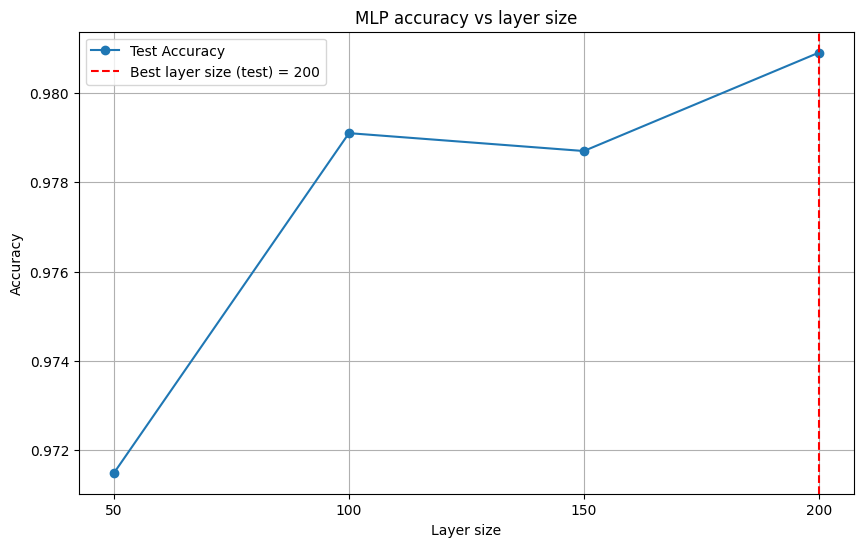

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(layer_sizes, test_scores, label='Test Accuracy', marker='o')
#plt.plot(layer_sizes, train_scores, label='Train Accuracy', marker='x')
plt.xlabel('Layer size')
plt.ylabel('Accuracy')
plt.title('MLP accuracy vs layer size')
plt.legend()
plt.xticks(layer_sizes)
plt.grid(True)

# Mark best layer
best_layer_size = layer_sizes[test_scores.index(max(test_scores))]
plt.axvline(x=best_layer_size, color='red', linestyle='--', label=f'Best layer size (test) = {best_layer_size}')
plt.legend()
plt.show()

#

# 5. Based on question 3 and 4, explain the key findings. 

### Accuracy increases as more layers are added but eventually the accuracy dips.  As more layer are added the network can learn more complex patterners.  However accuracy will eventuall dips due to the vanishing gradient problem.  Gradients becomes too small to be updated effectively as more layers makes the training unstable.

### Vanishing gradient - too many layers
### Overfitting - too many neurons

### Update: resubmission 31/5.  I made a mistake in Q3 code. The code should have been tuple([neurons] * l) to create a tuple layer or simply [neurons * l].  Howerver I made the mistake of (neurons) * l which just creates a bigger number instead of a tuple.  The interesting thing is even with the mistake it did create a simimlar climb and dip and then climb of accuracy score.

# 

# 6. As the deep neural network size is increased, double descent refers to the phenomenon in which the model performance initially improves, then gets worse, and ultimately improves again.  Create  two-layer  fully  connected  neural  networks, increase the network size by setting bigger hidden layer sizes, try to reproduce the double descent risk curve with the above MINIST dataset. Justify your experiment result.

In [15]:
layer_sizes = [50, 100, 150, 200, 250, 300, 350, 400, 500, 600, 700]
train_errors = []
test_errors = []
for neurons in layer_sizes:
    mlp_clf = MLPClassifier(
        hidden_layer_sizes=[neurons] * 2
        ,random_state=1
        ,max_iter=500
    )
    mlp_clf.fit(x_train_1d, y_train)
    
    score = mlp_clf.score(x_train_1d, y_train)
    train_errors.append(1 - score)
    score = mlp_clf.score(x_test_1d, y_test)
    test_errors.append(1 - score)
    print (f"Layer size {neurons} score: {score}")


Layer size 50 score: 0.9791
Layer size 100 score: 0.9784
Layer size 150 score: 0.9824
Layer size 200 score: 0.9843
Layer size 250 score: 0.9829
Layer size 300 score: 0.9807
Layer size 350 score: 0.9847
Layer size 400 score: 0.9868
Layer size 500 score: 0.9824
Layer size 600 score: 0.9853
Layer size 700 score: 0.9831


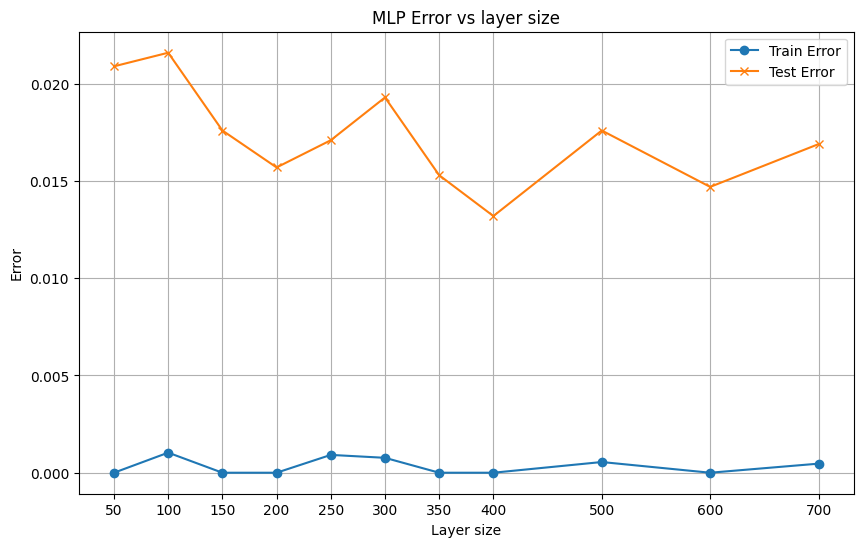

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(layer_sizes, train_errors, label='Train Error', marker='o')
plt.plot(layer_sizes, test_errors, label='Test Error', marker='x')
plt.xlabel('Layer size')
plt.ylabel('Error')
plt.title('MLP Error vs layer size')
plt.legend()
plt.xticks(layer_sizes)
plt.grid(True)

# Mark best layer
#best_layer_size = layer_sizes[scores.index(max(scores))]
#plt.axvline(x=best_layer_size, color='red', linestyle='--', label=f'Best layer size = {best_layer_size}')
plt.legend()
plt.show()

## The curve shows some characteristics of double descent. Test error peaks at 100 neurons (~0.022), drops to a local minimum at 200, rises again to a second peak at 300, then reaches its overall minimum at 400 neurons (~0.013). Beyond 400, however, the error does not continue to decrease, it rises at 500, dips at 600, and rises again at 700, suggesting no clear second descent within this range. Train error remains near zero across all layer sizes, indicating the interpolation threshold is crossed even at small layer sizes. The overall pattern is noisy, and a cleaner double descent trend may require more training iterations or a wider range of layer sizes.